# Antihypertensive Dose-Response Analysis

Analysis of a **synthetic** Phase I dose-response dataset for a hypothetical
antihypertensive drug.

## Overview

This notebook loads `data/dose_response.csv`, summarizes the data, fits a
linear dose-response model, and visualizes the fitted curve. All steps are
deterministic and use only the local CSV file, so the notebook is fully
reproducible without any network access.

- **Outcome:** systolic blood-pressure (SBP) reduction in mmHg
- **Exposure:** drug dose in mg

## 1. Load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path('data') / 'dose_response.csv')
df

   dose_mg  sbp_reduction_mmHg
0       10                 4.1
1       20                 7.8
2       30                11.9
3       40                15.2
4       50                19.6
5       60                23.1
6       70                27.4
7       80                31.5

## 2. Descriptive statistics

In [2]:
summary = df.describe().round(3)
summary

        dose_mg  sbp_reduction_mmHg
count    8.000              8.000
mean    45.000             17.575
std     24.495              9.562
min     10.000              4.100
25%     27.500             10.875
50%     45.000             17.400
75%     62.500             24.175
max     80.000             31.500

## 3. Linear regression

Fit an ordinary least-squares (OLS) model of the form `y = slope * dose + intercept`.

In [3]:
x = df['dose_mg'].to_numpy()
y = df['sbp_reduction_mmHg'].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

ss_res = float(np.sum((y - y_pred) ** 2))
ss_tot = float(np.sum((y - np.mean(y)) ** 2))
r2 = 1 - ss_res / ss_tot

print('Linear dose-response regression  (y = slope * dose + intercept)')
print(f'  slope     (mmHg per mg): {slope:.4f}')
print(f'  intercept (mmHg):       {intercept:.4f}')
print(f'  R^2:                    {r2:.4f}')

Linear dose-response regression  (y = slope * dose + intercept)
  slope     (mmHg per mg): 0.3902
  intercept (mmHg):       0.0143
  R^2:                    0.9993


## 4. Visualization

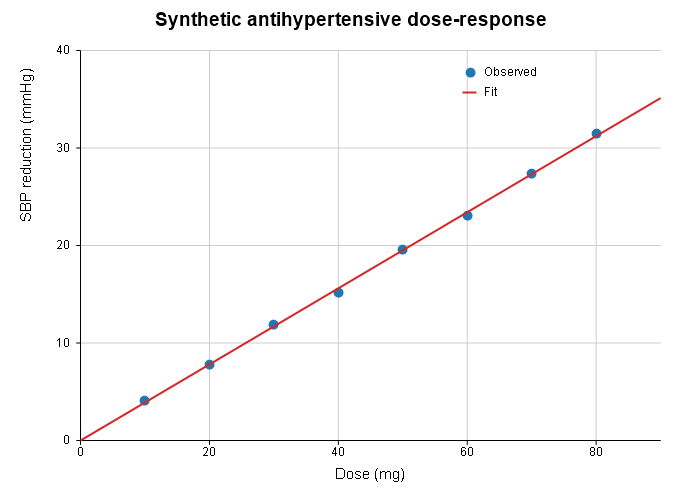

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=60, color='#1f77b4', label='Observed')
plt.plot(x, y_pred, linewidth=2, color='#d62728', label=f'Fit: y = {slope:.3f}x + {intercept:.3f}')
plt.xlabel('Dose (mg)')
plt.ylabel('SBP reduction (mmHg)')
plt.title('Synthetic antihypertensive dose-response')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Conclusion

The fitted model `y = 0.3902 * dose + 0.0143` explains about 99.9% of the
variance in this synthetic dataset (R² = 0.9993). The near-perfect fit is
expected because the data were generated with almost no noise. In real clinical
data, measurement error and biological variability would reduce R² and would
require formal confidence intervals and hypothesis tests.